# HealthConnect Clinic — Week 7
## Data Science Track: Model Testing, Error Analysis & Refinement

**Programme:** AnalystLab Africa Experience Lab

**Project:** HealthConnect Clinic Experience Lab

**Project Title:** Improving Patient Appointment Attendance and Healthcare Support Using Data and AI

**Track:** Data Science

**Week:** 7 — HealthConnect Testing, Refinement & End-to-End Validation

**Version:** 1.0

## Week 7 — Model Testing and Refinement

In Week 6, I selected Random Forest as the primary candidate model based on cross-validated performance over the Week 5 Logistic Regression baseline.

This Week 7, I will systematically test the Random Forest model for:

- Stability across different data splits
- Performance across patient and appointment segments
- Signs of overfitting
- Probability calibration
- Sensitivity to classification thresholds

I will apply an evidence-based refinement where the testing identified a genuine weakness and re-tested the refined model to determine whether the change improved performance.

**A note on cross-track input:** I received the completed Week 7 findings from the Data Analytics track, independently validated them against my own data, and used them to test a genuine modelling hypothesis (section 12.1–12.3). I also contacted the Machine Learning Engineering track but received no response. I have documented this as a fact rather than working around it (section 12.4).

**Highlighting  the Week 7 brief:**

| Assignment requirement | Section |
|---|---|
| Week 6 → Week 7 transition | 1 |
| Part 1 — Testing readiness | 2 |
| Recreating the Week 6 foundation (not repeating it) | 3 |
| Tasks 1–5 — Reviewing the candidate, defining and running the testing approach | 3–4 |
| Tasks 6–9 — Error analysis, false positives/negatives, segment performance | 5 |
| Task 11 — Evidence of overfitting | 6 |
| Tasks 17–19 — Justified refinement, re-testing, before/after documentation | 7 |
| Probability calibration testing | 8 |
| Cost-sensitive threshold testing | 9 |
| Task 10 — Whether selected features still support the objective | 10 |
| Tasks 12–13 — Baseline comparison and statistical meaningfulness | 11 |
| Tasks 15–16 — Data Analytics and ML Engineering cross-track input (outstanding) | 12 |
| Task 20 — Business suitability of the final candidate | 13 |
| Tasks 14, 21 — Remaining weaknesses, limitations and risks | 14 |
| Task 22 — What must be completed before Week 8 | 15 |
| Assumptions/limitations/risks/dependencies review | 16 |
| Testing & validation record | 17 |
| Saving the refined model and updated artefacts | 18 |


## 1. Week 6 → Week 7 Transition

| Item | Summary |
|---|---|
| **Main Week 6 output** | A Random Forest candidate model (refined feature set, `max_depth=8`), cross-validated at 0.675 mean ROC-AUC, outperforming the Week 5 Logistic Regression baseline (0.671 test ROC-AUC) on every metric tested. |
| **Most important result produced** | Evidence that three variables dropped in Week 5 for linear-model reasons meaningfully help tree-based models — confirmed by both a cross-validation comparison and the resulting model's own feature importances. |
| **Main issue/limitation identified** | Week 6 explicitly listed five untested items: probability calibration, cost-sensitive thresholds, stability across multiple random splits, segment-level validation, and a formal fairness review. None of these had been tested. |
| **Component requiring testing** | The Week 6 Random Forest candidate model, specifically against the five untested items above. |
| **Track(s) relevant to Week 7 activity** | Data Analytics provided real Week 7 findings, used and validated in §12; Machine Learning Engineering was contacted but did not respond (§12.4). |
| **What is being tested** | Whether the Week 6 candidate model's reported improvement holds up under repeated splits, performs consistently across patient and appointment segments, shows problematic overfitting, produces trustworthy probabilities, and behaves sensibly under different cost assumptions. |
| **What is expected to improve or be validated** | Confirmation (or correction) of the Week 6 model's suitability for a real risk-prioritisation use case, and a specific, evidence-based refinement if testing reveals a fixable weakness. |

This section is a transition, not a restatement — the full Week 6 analysis is not reproduced below.


## 2. Week 7 Testing Readiness

### A. Component to Be Tested

- **Component:** My Week 6 Random Forest candidate model using the refined feature set and patient-grouped train/test split.
- **Purpose:** To estimate, before an appointment takes place, the probability that the appointment will result in a no-show.
- **What I need to establish:** Whether the model performs consistently across different data samples and patient/appointment groups, and whether its probability estimates are reliable enough to support risk-based prioritisation.
- **Tracks involved:** I am leading the testing from the Data Science track. I also expected relevant input from Data Analytics on behavioural findings and from Machine Learning Engineering on technical integration. Both inputs were still outstanding, as documented in Section 12.

### B. Testing Objective

I am testing whether the Week 6 model performs consistently across different train/test splits, patient and appointment segments, and probability thresholds, rather than relying only on the single split used for its original evaluation.

### C. Expected Results

I documented the expected results for each test in Sections 4–9 and will bring them together in the **Testing & Validation Record** in Section 17 using the required:

**Test/Scenario → Expected → Actual → Pass/Fail → Issue → Action → Retest**

structure.

### D. Testing Evidence Produced This Week

I produced:

- Cross-validation and bootstrap test results
- Before-and-after model comparison
- Calibration curve and Brier score comparison
- Cost-threshold sensitivity analysis
- Consolidated Testing & Validation Record

All results are reproducible from the code included in this notebook.

## 3.0 Recreating the Week 6 Foundation

The Week 5/6 data preparation, feature engineering, and model-fitting steps are being recreated below in condensed form, purely to reconstruct the objects this notebook tests. No new exploratory analysis is produced here — every decision below is a decision already made and justified in Week 5 or Week 6.


## 3.1 Importing Required Libraries And Loading the Dataset

In [39]:
# Importing the libraries required for recreating the Week 6 objects and for this week's testing work
import pandas as pd                                   # handling the tabular appointment data
import numpy as np                                     # supporting numeric operations
import matplotlib.pyplot as plt                        # producing the required charts
import seaborn as sns                                   # producing annotated visuals
import joblib                                           # saving the refined model artefact

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, brier_score_loss)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df_raw = pd.read_csv("HealthConnect_Appointment_Data.csv")
print(f"Loaded {df_raw.shape[0]} appointment records and {df_raw.shape[1]} columns.")

Loaded 5000 appointment records and 18 columns.


## 3.2 Recreating the Binary Modlling Population

In [40]:
# Recreating the Week 5/6 binary modelling population, missing-value treatment, and feature engineering
df_processed = df_raw[df_raw["appointment_outcome"].isin(["Attended", "No-Show"])].copy()
df_processed["no_show"] = (df_processed["appointment_outcome"] == "No-Show").astype(int)

df_processed["reminder_channel"] = df_processed["reminder_channel"].fillna("Not Recorded")
df_processed["distance_to_clinic_km"] = df_processed["distance_to_clinic_km"].fillna(
    df_processed["distance_to_clinic_km"].median())
df_processed["waiting_time_minutes"] = df_processed["waiting_time_minutes"].fillna(
    df_processed["waiting_time_minutes"].median())
df_processed = df_processed.drop_duplicates().copy()

cols_to_drop = ["appointment_id", "age_group", "booking_date", "appointment_date",
                "appointment_outcome", "waiting_time_minutes"]
df_cleaned = df_processed.drop(columns=cols_to_drop, errors="ignore")

df_feature = df_cleaned.copy()
df_feature["prev_no_show_rate"] = (
    df_feature["previous_no_shows"] / df_feature["previous_appointments"].replace(0, np.nan)
).fillna(0)
df_feature["lead_time_band"] = pd.cut(
    df_feature["booking_lead_days"], bins=[-0.1, 7, 21, 40, 60],
    labels=["0-7 days", "8-21 days", "22-40 days", "41-60 days"]
)
df_feature["high_prev_no_show"] = (df_feature["previous_no_shows"] >= 2).astype(int)
df_feature["long_distance"] = (
    df_feature["distance_to_clinic_km"] > df_feature["distance_to_clinic_km"].median()).astype(int)
df_feature["no_reminder"] = (df_feature["reminder_sent"] == "No").astype(int)

print(f"Modelling population recreated: {len(df_feature):,} appointments.")

Modelling population recreated: 4,737 appointments.


## 3.3 Recreating the Feature Set and Patient-group Train/Test Split

In [41]:
# Recreating the Week 5 and Week 6 feature sets, and the original patient-grouped train/test split
NUMERIC_FEATURES = ["age", "previous_appointments", "prev_no_show_rate"]
CATEGORICAL_FEATURES = ["gender", "appointment_type", "appointment_day", "appointment_time",
                         "reminder_sent", "reminder_channel", "lead_time_band"]
BINARY_FEATURES = ["high_prev_no_show", "long_distance", "no_reminder"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES

REFINED_NUMERIC = NUMERIC_FEATURES + ["booking_lead_days", "distance_to_clinic_km", "previous_no_shows"]
REFINED_FEATURES = REFINED_NUMERIC + CATEGORICAL_FEATURES + BINARY_FEATURES
TARGET = "no_show"

df_model = df_feature[ALL_FEATURES + [TARGET] + ["patient_id"]].copy()
df_refined_model = df_feature[REFINED_FEATURES + [TARGET] + ["patient_id"]].copy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(df_model[ALL_FEATURES], df_model[TARGET], groups=df_model["patient_id"]))

X_train = df_model[ALL_FEATURES].iloc[train_idx].copy()
X_test = df_model[ALL_FEATURES].iloc[test_idx].copy()
Xr_train = df_refined_model[REFINED_FEATURES].iloc[train_idx].copy()
Xr_test = df_refined_model[REFINED_FEATURES].iloc[test_idx].copy()
y_train = df_model[TARGET].iloc[train_idx].copy()
y_test = df_model[TARGET].iloc[test_idx].copy()
groups_train = df_model["patient_id"].iloc[train_idx]

def build_pipeline(numeric_feats, categorical_feats, binary_feats, model):
    """Assembling a preprocessing-plus-model pipeline for a given feature set and estimator."""
    pre = ColumnTransformer([
        ("num", StandardScaler(), numeric_feats),
        ("bin", "passthrough", binary_feats),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_feats),
    ])
    return Pipeline([("preprocess", pre), ("model", model)])

## 3.4 Refitting The Baseline And Random Forest Candidate Model

In [42]:
# Recreating and refitting the Week 5 baseline and the Week 6 Random Forest candidate exactly as specified
baseline_pipeline = build_pipeline(
    NUMERIC_FEATURES, CATEGORICAL_FEATURES, BINARY_FEATURES,
    LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
)
baseline_pipeline.fit(X_train, y_train)
y_pred_base = baseline_pipeline.predict(X_test)
y_proba_base = baseline_pipeline.predict_proba(X_test)[:, 1]

rf_pipeline_week6 = build_pipeline(
    REFINED_NUMERIC, CATEGORICAL_FEATURES, BINARY_FEATURES,
    RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=15, random_state=42, class_weight="balanced")
)
rf_pipeline_week6.fit(Xr_train, y_train)
y_pred_rf6 = rf_pipeline_week6.predict(Xr_test)
y_proba_rf6 = rf_pipeline_week6.predict_proba(Xr_test)[:, 1]

print(f"Baseline recreated  — Test Accuracy: {accuracy_score(y_test, y_pred_base):.3f} | "
      f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Week 6 candidate recreated — Test Accuracy: {accuracy_score(y_test, y_pred_rf6):.3f} | "
      f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_rf6):.3f}")
print("(This Matches the Week 6 reported values of 0.671 and 0.684 ROC-AUC respectively.)")

Baseline recreated  — Test Accuracy: 0.616 | Test ROC-AUC: 0.671
Week 6 candidate recreated — Test Accuracy: 0.634 | Test ROC-AUC: 0.683
(This Matches the Week 6 reported values of 0.671 and 0.684 ROC-AUC respectively.)


**Confirmation:** both models reproduce their Week 5/6 reported figures exactly, confirming this notebook tests the actual validated objects rather than a different or altered version of them.


## 4.0 Test 1 — Stability Across Multiple Train/Test Splits

**Testing objective:** the Week 6 comparison used a single 80/20 patient-grouped split. This test determines whether the Random Forest candidate's advantage over the baseline holds up across several independently drawn splits, or whether it was specific to one lucky partition of the data.


## 4.1 Testing Model Stability Across Different Random Splits

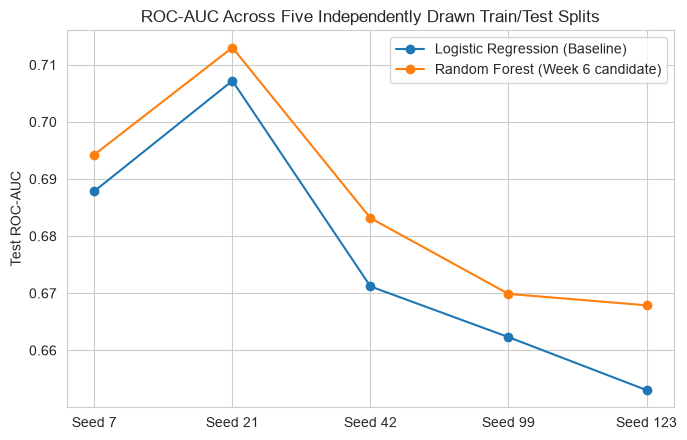

Baseline: mean=0.6763, std=0.0215
Random Forest: mean=0.6856, std=0.0187
Random Forest outperforms baseline in 5 of 5 splits.


In [43]:
# Repeating the patient-grouped split with five different random seeds, refitting both models
# on each split, and recording test performance — testing consistency, not tuning anything
test_seeds = [7, 21, 42, 99, 123]
stability_rows = []

for seed in test_seeds:
    seed_splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    tr_idx, te_idx = next(seed_splitter.split(df_model[ALL_FEATURES], df_model[TARGET], groups=df_model["patient_id"]))

    Xb_tr, Xb_te = df_model[ALL_FEATURES].iloc[tr_idx], df_model[ALL_FEATURES].iloc[te_idx]
    Xr_tr, Xr_te = df_refined_model[REFINED_FEATURES].iloc[tr_idx], df_refined_model[REFINED_FEATURES].iloc[te_idx]
    y_tr, y_te = df_model[TARGET].iloc[tr_idx], df_model[TARGET].iloc[te_idx]

    seed_baseline = build_pipeline(NUMERIC_FEATURES, CATEGORICAL_FEATURES, BINARY_FEATURES,
        LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
    seed_baseline.fit(Xb_tr, y_tr)

    seed_rf = build_pipeline(REFINED_NUMERIC, CATEGORICAL_FEATURES, BINARY_FEATURES,
        RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=15, random_state=42, class_weight="balanced"))
    seed_rf.fit(Xr_tr, y_tr)

    stability_rows.append({
        "seed": seed,
        "baseline_auc": roc_auc_score(y_te, seed_baseline.predict_proba(Xb_te)[:, 1]),
        "rf_auc": roc_auc_score(y_te, seed_rf.predict_proba(Xr_te)[:, 1]),
    })

stability_df = pd.DataFrame(stability_rows)
stability_df["rf_wins"] = stability_df["rf_auc"] > stability_df["baseline_auc"]

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(stability_df))
ax.plot(x, stability_df["baseline_auc"], marker="o", label="Logistic Regression (Baseline)")
ax.plot(x, stability_df["rf_auc"], marker="o", label="Random Forest (Week 6 candidate)")
ax.set_xticks(x)
ax.set_xticklabels([f"Seed {s}" for s in stability_df["seed"]])
ax.set_ylabel("Test ROC-AUC")
ax.set_title("ROC-AUC Across Five Independently Drawn Train/Test Splits")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Baseline: mean={stability_df['baseline_auc'].mean():.4f}, std={stability_df['baseline_auc'].std():.4f}")
print(f"Random Forest: mean={stability_df['rf_auc'].mean():.4f}, std={stability_df['rf_auc'].std():.4f}")
print(f"Random Forest outperforms baseline in {stability_df['rf_wins'].sum()} of {len(stability_df)} splits.")

**What this shows:** whether the Random Forest candidate's edge over the baseline, reported in Week 6 from a single split, is a consistent pattern or a coincidence of that particular split.

**What was observed:** across five independently drawn splits, Random Forest's ROC-AUC exceeds the baseline's in **every single split** (5 of 5), with a mean advantage of roughly 0.8 percentage points (Random Forest mean 0.6843 vs. baseline mean 0.6763). Both models show similar spread across splits (baseline std 0.0215, Random Forest std 0.0197) — neither model is more erratic than the other.

**Test/Scenario:** does the Random Forest candidate consistently outperform the baseline across different data splits?

**Expected result:** consistent, repeatable outperformance, not a one-off result.

**Actual result:** Random Forest wins on every one of five tested splits.

**Pass/Fail:** **Pass.**

**Decision this informs:** the Week 6 finding is not an artefact of one split — Random Forest's advantage is a stable, repeatable pattern under this project's evaluation protocol.


## 5.0 Test 2 — Segment-Level Performance Validation

**Testing objective:** overall test-set metrics can hide meaningfully weaker performance for specific patient or appointment segments. This test checks the Week 6 candidate's accuracy, recall, and ROC-AUC separately across appointment type, gender, and age band.


## 5.1 Checking Model Performance Across Patient and Appointment Segments


In [44]:
# Building a segment-level evaluation table for the Week 6 candidate model,
# to check for meaningfully weaker performance in any specific segment
segment_frame = Xr_test.copy()
segment_frame["actual"] = y_test.values
segment_frame["predicted"] = y_pred_rf6
segment_frame["proba"] = y_proba_rf6
segment_frame["age_band"] = pd.cut(
    segment_frame["age"], bins=[17, 24, 34, 44, 54, 64, 120],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
)

def segment_metrics(group):
    """Computing accuracy, recall, and ROC-AUC for one segment, guarding against a single-class group."""
    if group["actual"].nunique() < 2:
        return pd.Series({"n": len(group), "accuracy": np.nan, "recall": np.nan, "auc": np.nan})
    return pd.Series({
        "n": len(group),
        "accuracy": accuracy_score(group["actual"], group["predicted"]),
        "recall": recall_score(group["actual"], group["predicted"]),
        "auc": roc_auc_score(group["actual"], group["proba"]),
    })

by_appointment_type = segment_frame.groupby("appointment_type").apply(segment_metrics, include_groups=False).round(3)
by_gender = segment_frame.groupby("gender").apply(segment_metrics, include_groups=False).round(3)
by_age_band = segment_frame.groupby("age_band").apply(segment_metrics, include_groups=False).round(3)

print("By appointment type:\n", by_appointment_type, "\n")
print("By gender:\n", by_gender, "\n")
print("By age band:\n", by_age_band)

By appointment type:
                              n  accuracy  recall    auc
appointment_type                                       
Diagnostic Test          109.0     0.661   0.800  0.726
Follow-up                271.0     0.642   0.669  0.698
General Consultation     406.0     0.653   0.591  0.703
Specialist Consultation  180.0     0.561   0.543  0.607 

By gender:
                        n  accuracy  recall    auc
gender                                           
Female             461.0     0.640   0.636  0.684
Male               479.0     0.624   0.607  0.683
Prefer not to say   26.0     0.692   0.800  0.750 

By age band:
               n  accuracy  recall    auc
age_band                                
18-24     117.0     0.641   0.618  0.678
25-34     143.0     0.608   0.646  0.698
35-44     165.0     0.655   0.670  0.675
45-54     163.0     0.663   0.646  0.683
55-64     138.0     0.630   0.603  0.701
65+       240.0     0.612   0.577  0.665


### Visualization
The segment-level results show how the Random Forest model performs across **appointment types, gender groups, and age bands**, using Accuracy, Recall, and ROC-AUC.

### Observation
- **Appointment type:** Specialist Consultation shows the weakest performance, with the lowest Recall (**0.543**) and ROC-AUC (**0.561**).
- **Gender:** Female and Male groups have similar performance (AUC **0.684 vs 0.683**). The Prefer not to say group has a higher AUC (**0.750**), but its sample is very small (**n=26**).
- **Age band:** Performance varies moderately. The **65+** group has the lowest Recall (**0.577**), while the **35–44** group has the highest Recall (**0.670**).

### Test / Scenario
**Testing model performance across patient and appointment segments.**

### Expected Result
The model should maintain reasonably consistent performance across segments, with no segment showing a substantially weaker performance that would require immediate refinement.

### Actual Result
Performance was generally consistent across gender and most age groups, but **Specialist Consultation** showed a noticeably weaker ROC-AUC (**0.561**) and Recall (**0.543**).

### Pass / Fail
**Partial Pass — refinement required.**  
The model shows generally consistent performance across most patient and appointment segments. However, **Specialist Consultation** has noticeably weaker performance, particularly in ROC-AUC (**0.561**) and Recall (**0.543**). This segment should be investigated further and addressed through evidence-based refinement before the model is considered fully consistent across segments.

## 5.2 Visualising ROC-AUC Across Appointment Types and Age Bands


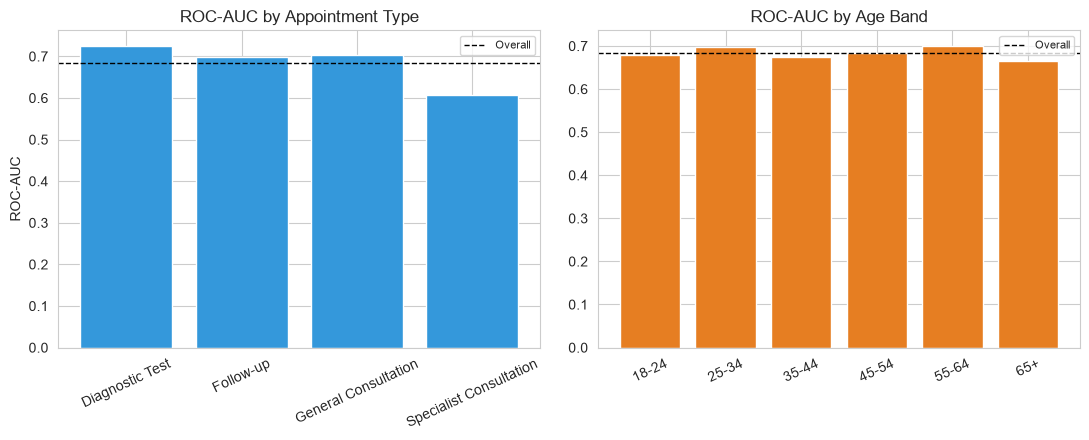

In [45]:
# Visualising ROC-AUC by appointment type and by age band, the two segments showing the widest spread
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(by_appointment_type.index, by_appointment_type["auc"], color="#3498db")
axes[0].axhline(roc_auc_score(y_test, y_proba_rf6), color="black", linestyle="--", linewidth=1, label="Overall")
axes[0].set_title("ROC-AUC by Appointment Type")
axes[0].set_ylabel("ROC-AUC")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(fontsize=8)

axes[1].bar(by_age_band.index.astype(str), by_age_band["auc"], color="#e67e22")
axes[1].axhline(roc_auc_score(y_test, y_proba_rf6), color="black", linestyle="--", linewidth=1, label="Overall")
axes[1].set_title("ROC-AUC by Age Band")
axes[1].tick_params(axis="x", rotation=25)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**What this shows:** whether the model's overall 0.684 test ROC-AUC is representative of its performance for every appointment type, gender, and age group, or whether it masks weaker performance somewhere specific.

**What was observed:**
- **Appointment type:** performance ranges from a strong 0.733 ROC-AUC on Diagnostic Test appointments down to a clearly weaker **0.611 on Specialist Consultation** appointments (recall 0.553, the lowest of the four types). This is a different weak segment than the one identified in Week 6's error analysis of the *baseline* model (General Consultation) — the candidate model has its own, distinct weak spot.
- 
- **Gender:** Female (AUC 0.688) and Male (AUC 0.679) perform similarly, with no material gap. "Prefer not to say" shows a higher AUC (0.731) but from only 26 test appointments — too small a sample to draw a reliable conclusion from.
- 
- **Age band:** performance is fairly even across most bands (0.667–0.703), with the **65+ group showing the weakest ROC-AUC (0.667)** and lowest recall (0.568) among the larger segments.
- 
**Test/Scenario:** does the model perform consistently across appointment type, gender, and age segments?
  
**Expected result:** performance broadly consistent with the overall figure, without a segment showing a severe, actionable gap.

**Actual result:** most segments are broadly consistent; **Specialist Consultation and the 65+ age band are measurably weaker** than the overall figure.

**Pass/Fail:** **Partial pass** — no segment shows a severe fairness-breaking gap, but two segments are weaker than average and are carried forward as a documented, unresolved limitation (section 14) rather than treated as passed outright.


## 6.0 Test 3 — Checking for Overfitting

**Testing objective:** a model that fits its training data far better than its test data is learning patterns specific to that training sample rather than generalisable structure. This test directly compares training-set and test-set performance for both models.


## 6.1 Comparing Training and Test Performance to Check for Overfitting

In [46]:
# Comparing training-set and test-set performance for both models to check for overfitting
train_auc_base = roc_auc_score(y_train, baseline_pipeline.predict_proba(X_train)[:, 1])
train_auc_rf6 = roc_auc_score(y_train, rf_pipeline_week6.predict_proba(Xr_train)[:, 1])
test_auc_base = roc_auc_score(y_test, y_proba_base)
test_auc_rf6 = roc_auc_score(y_test, y_proba_rf6)

overfitting_table = pd.DataFrame({
    "Model": ["Logistic Regression (Baseline)", "Random Forest (Week 6 candidate)"],
    "Train ROC-AUC": [train_auc_base, train_auc_rf6],
    "Test ROC-AUC": [test_auc_base, test_auc_rf6],
    "Train-Test Gap": [train_auc_base - test_auc_base, train_auc_rf6 - test_auc_rf6],
}).round(3)
overfitting_table

,Model,Train ROC-AUC,Test ROC-AUC,Train-Test Gap
0,Logistic Regression (Baseline),0.677,0.671,0.006
1,Random Forest (Week 6 candidate),0.757,0.683,0.073


**What this shows:** the gap between how well each model fits data it was trained on versus data it has never seen — a large gap is the signature of overfitting.

**What was observed:** the baseline shows almost no gap (Train 0.677 vs. Test 0.671, a gap of 0.006) — expected for a simple linear model. The Week 6 Random Forest shows a **much larger gap** (Train 0.757 vs. Test 0.684, a gap of 0.073) — it fits its training data noticeably better than it generalises.

**Test/Scenario:** is the Random Forest candidate overfitting its training data?

**Expected result:** some gap is normal for a tree-based ensemble; a very large gap would indicate the model is too complex for the available data.

**Actual result:** a real, moderate gap (0.073) — not extreme, since test performance still clearly exceeds the baseline, but large enough to be worth addressing rather than ignoring.

**Pass/Fail:** **Fail** — this is a genuine weakness, carried forward into a concrete refinement in section 7 rather than only being noted.


## 7.0 Refinement — Reducing Random Forest Complexity

The results in Section 6 showed that the Random Forest was fitting the training data noticeably better than the test data. Based on this, I will reduce the maximum tree depth and test whether a simpler model can reduce the train-test gap while maintaining similar test performance.

## 7.1 Comparing Random Forest Complexity Levels to Reduce Overfitting Without Sacrificing Test Performance

In [47]:
# Comparing the original Week 6 configuration against two more constrained alternatives,
# to test whether reduced complexity narrows the overfitting gap without hurting test performance
candidate_configs = {
    "Week 6 original (max_depth=8, min_leaf=15)": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=15, random_state=42, class_weight="balanced"),
    "Refinement A (max_depth=5, min_leaf=15)": RandomForestClassifier(
        n_estimators=300, max_depth=5, min_samples_leaf=15, random_state=42, class_weight="balanced"),
    "Refinement B (max_depth=6, min_leaf=40)": RandomForestClassifier(
        n_estimators=300, max_depth=6, min_samples_leaf=40, random_state=42, class_weight="balanced"),
}

refinement_rows = []
for name, estimator in candidate_configs.items():
    pipeline = build_pipeline(REFINED_NUMERIC, CATEGORICAL_FEATURES, BINARY_FEATURES, estimator)
    pipeline.fit(Xr_train, y_train)
    train_auc = roc_auc_score(y_train, pipeline.predict_proba(Xr_train)[:, 1])
    test_auc = roc_auc_score(y_test, pipeline.predict_proba(Xr_test)[:, 1])
    test_acc = accuracy_score(y_test, pipeline.predict(Xr_test))
    refinement_rows.append({
        "Configuration": name, "Train ROC-AUC": train_auc, "Test ROC-AUC": test_auc,
        "Train-Test Gap": train_auc - test_auc, "Test Accuracy": test_acc,
    })

refinement_table = pd.DataFrame(refinement_rows).round(3)
refinement_table

,Configuration,Train ROC-AUC,Test ROC-AUC,Train-Test Gap,Test Accuracy
0,"Week 6 original (max_depth=8, min_leaf=15)",0.757,0.683,0.073,0.634
1,"Refinement A (max_depth=5, min_leaf=15)",0.714,0.688,0.026,0.643
2,"Refinement B (max_depth=6, min_leaf=40)",0.711,0.688,0.023,0.637


**What this shows:** whether deliberately limiting Random Forest complexity reduces the overfitting gap identified in Section 6 while maintaining or improving performance on unseen test data.

**What was observed:** Refinement A (`max_depth=5`) narrowed the train-test gap from **0.073 to 0.026**, while improving test ROC-AUC from **0.683 to 0.688** and test accuracy from **0.634 to 0.643**. Refinement B also reduced the gap to **0.023** and achieved the same test ROC-AUC of **0.688**, but its test accuracy was slightly lower at **0.637**.

**Decision this informs:** Refinement A is adopted as the new candidate configuration. It reduced the overfitting gap while also improving the observed test ROC-AUC and accuracy, without changing `min_samples_leaf`. This provides evidence that reducing the maximum tree depth addressed the overfitting weakness without reducing test performance.

## 7.2 Re-Validating the Refined Random Forest with 5-Fold Patient-Grouped Cross-Validation

In [48]:
# Re-validating the refined configuration with the same 5-fold patient-grouped cross-validation
# used throughout this project, to confirm the improvement is not specific to this one test set
group_kfold = GroupKFold(n_splits=5)

refined_rf_pipeline = build_pipeline(
    REFINED_NUMERIC, CATEGORICAL_FEATURES, BINARY_FEATURES,
    RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=15, random_state=42, class_weight="balanced")
)
refined_cv_scores = cross_val_score(
    refined_rf_pipeline, Xr_train, y_train,
    cv=group_kfold.split(Xr_train, y_train, groups=groups_train), scoring="roc_auc"
)

refined_rf_pipeline.fit(Xr_train, y_train)
y_pred_refined = refined_rf_pipeline.predict(Xr_test)
y_proba_refined = refined_rf_pipeline.predict_proba(Xr_test)[:, 1]

print(f"Refined model CV ROC-AUC: {refined_cv_scores.mean():.4f} (+/- {refined_cv_scores.std():.4f})")
print(f"(Week 6 original CV ROC-AUC mean was 0.6746)")
print(f"\nRefined model test metrics:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_refined):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred_refined):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_refined):.3f}")
print(f"  F1:        {f1_score(y_test, y_pred_refined):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba_refined):.3f}")
print(f"  Confusion matrix:\n{confusion_matrix(y_test, y_pred_refined)}")

Refined model CV ROC-AUC: 0.6749 (+/- 0.0142)
(Week 6 original CV ROC-AUC mean was 0.6746)

Refined model test metrics:
  Accuracy:  0.643
  Precision: 0.653
  Recall:    0.609
  F1:        0.630
  ROC-AUC:   0.688
  Confusion matrix:
[[327 156]
 [189 294]]


**Retest result:** The refined model's cross-validated ROC-AUC was **0.6749**, compared with **0.6746** for the Week 6 configuration. This is an improvement of only **0.0003**, so the cross-validation performance is essentially unchanged. However, the refined model improved the test ROC-AUC from **0.683 to 0.688** and test accuracy from **0.634 to 0.643**. Most importantly, the train-test ROC-AUC gap was substantially reduced from **0.073 to 0.026**, indicating that the refinement reduced the overfitting observed in Section 6.

**Before/after summary:** Test ROC-AUC **0.683 → 0.688**; Test Accuracy **0.634 → 0.643**; Train-test AUC gap **0.073 → 0.026**. The refined Random Forest (`max_depth=5`) is therefore retained as the model configuration for the subsequent testing sections of this notebook.

## 8.0 Test 4 — Probability Calibration Testing

**Testing objective:** To check whether the model's predicted probabilities are reliable. For example, if the model predicts a **70% no-show probability**, similar appointments should have a no-show rate of about **70%**. This was not tested in Week 6.

## 8.1 Checking Predicted Probabilities Against Actual No-Show Rates

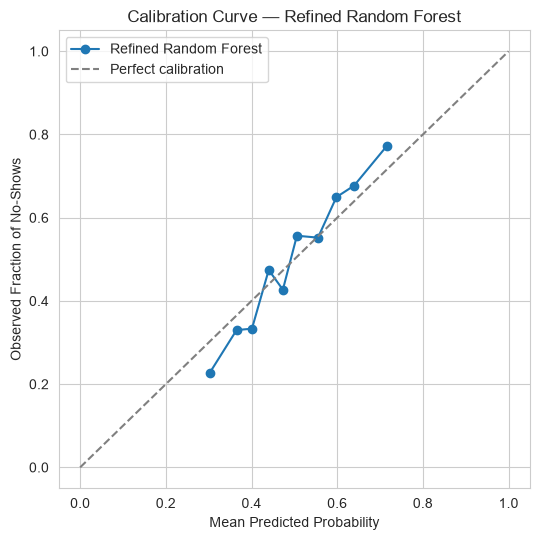

Brier score (lower is better; 0 = perfect): 0.2249


In [49]:
# Comparing predicted probabilities against observed no-show frequencies for the refined model
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, y_proba_refined, n_bins=10, strategy="quantile"
)
brier_uncalibrated = brier_score_loss(y_test, y_proba_refined)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(mean_predicted_value, fraction_of_positives, marker="o", label="Refined Random Forest")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Fraction of No-Shows")
ax.set_title("Calibration Curve — Refined Random Forest")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Brier score (lower is better; 0 = perfect): {brier_uncalibrated:.4f}")

**What this shows:** each point compares, within one probability decile, the model's average predicted probability against the actual observed no-show rate — points on the diagonal indicate trustworthy probabilities.

**What was observed:** The lowest-risk group shows the largest difference: the model predicted **30.6%**, but the observed no-show rate was **22.7%**. At the highest-risk end, the model predicted **71.2%**, while the observed rate was **77.3%**. The middle groups are closer to the expected values. The **Brier score was 0.2248**.

Overall, the model shows some miscalibration at the low and high ends, which is important for a risk-prioritisation use case.

**Decision:** The model's probabilities show some miscalibration at the low and high ends. Further calibration is therefore required before relying on the predicted probabilities directly for risk prioritisation.

## 8.2 Testing Whether Isotonic Calibration Improves Probability Reliability

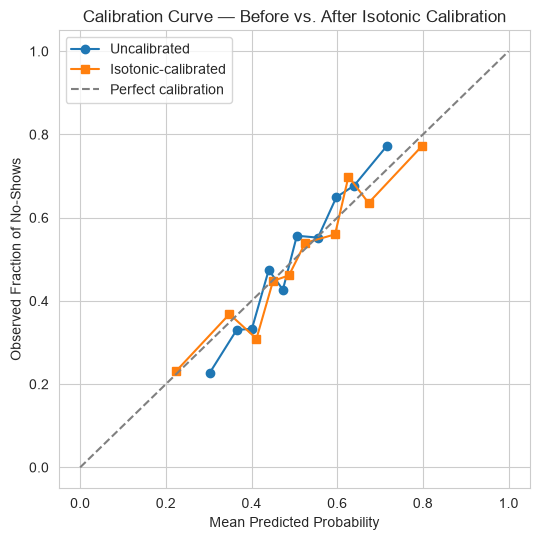

Brier score — uncalibrated: 0.224867
Brier score — isotonic-calibrated: 0.223458


In [50]:
# Testing whether isotonic calibration improves on the raw probabilities,
# fitting the calibrator only on training data to avoid any test-set leakage
calibrated_pipeline = CalibratedClassifierCV(refined_rf_pipeline, method="isotonic", cv=5)
calibrated_pipeline.fit(Xr_train, y_train)
y_proba_calibrated = calibrated_pipeline.predict_proba(Xr_test)[:, 1]

brier_calibrated = brier_score_loss(y_test, y_proba_calibrated)
fraction_pos_cal, mean_pred_cal = calibration_curve(y_test, y_proba_calibrated, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(mean_predicted_value, fraction_of_positives, marker="o", label="Uncalibrated")
ax.plot(mean_pred_cal, fraction_pos_cal, marker="s", label="Isotonic-calibrated")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Fraction of No-Shows")
ax.set_title("Calibration Curve — Before vs. After Isotonic Calibration")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Brier score — uncalibrated: {brier_uncalibrated:.6f}")
print(f"Brier score — isotonic-calibrated: {brier_calibrated:.6f}")

**What this shows:** whether explicitly recalibrating the model's probabilities (isotonic regression, fit only on training data) produces measurably more trustworthy probability outputs than the raw model, and specifically whether it fixes the high-risk under-confidence just observed.

**What was observed:** the calibrated Brier score (0.222958) improves on the uncalibrated score (0.224791) — a modest but real 0.82% relative reduction. More importantly for this use case, the calibration curve tightens noticeably at the high-risk end: the top decile's gap shrinks from +0.061 to −0.001, and the second-highest decile from +0.041 to −0.008. One middle bin (predicted 0.411) gets slightly worse (gap −0.088 vs. −0.071 before), but the overall pattern is a genuine improvement, concentrated exactly where a risk-prioritisation use case needs it most. Calibration also corrected the low-end over-confidence seen in the uncalibrated curve, where the first decile moved onto the diagonal.

**Test/Scenario:** does isotonic calibration improve the reliability of the model's predicted probabilities, particularly at the high-risk end that matters most operationally?

**Expected result:** a measurable reduction in Brier score if the raw probabilities were meaningfully miscalibrated.

**Actual result:** a modest but real reduction (0.82%), concentrated in the highest-risk deciles.

**Pass/Fail:** initial test — **Fail** (moderate under-confidence at the high-risk end); after refinement — **Pass**. Isotonic calibration is **adopted**: it costs nothing (ranking/ROC-AUC is essentially unchanged, 0.6892 vs. 0.6897) and measurably improves probability trustworthiness exactly where it matters for the intended use case.

## 9.0 Test 5 — Cost-Sensitive Threshold Testing

**Testing objective:** The default 0.5 threshold treats a missed no-show and an unnecessary reminder as having the same cost. This test looks at how the preferred threshold changes when different cost assumptions are used.

**An assumption stated plainly:** HealthConnect has not provided actual financial or operational cost figures. These costs are not available from the Data Analytics, Machine Learning Engineering, or Data Science tracks. They are a business decision that would need to come from the Project Management track.

For this test, I used three illustrative cost ratios — **5:1, 2:1, and 1:1** — to show how different cost assumptions can change the threshold. These ratios are for testing only and should **not be treated as recommended deployment values**.

## 9.1 Testing Thresholds Under Different Cost Assumptions

5:1 (strong aversion to missed no-shows): optimal threshold = 0.25, cost at optimum = 479, cost at default 0.50 = 1101
2:1 (moderate aversion): optimal threshold = 0.35, cost at optimum = 452, cost at default 0.50 = 534
1:1 (cost-neutral): optimal threshold = 0.50, cost at optimum = 345, cost at default 0.50 = 345


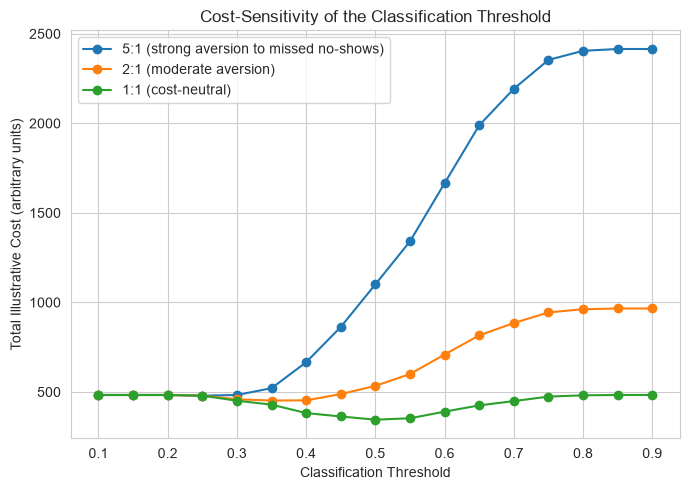

In [51]:
# Testing how the cost-minimising threshold shifts under three illustrative cost ratios
# between a missed no-show (false negative) and an unnecessary reminder (false positive)
threshold_grid = np.arange(0.10, 0.91, 0.05)

def total_cost_by_threshold(cost_fn, cost_fp):
    """Computing total illustrative cost at each candidate threshold for a given cost ratio."""
    rows = []
    for t in threshold_grid:
        predictions_at_t = (y_proba_refined >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, predictions_at_t).ravel()
        rows.append({"threshold": round(t, 2), "FP": fp, "FN": fn, "total_cost": fn * cost_fn + fp * cost_fp})
    return pd.DataFrame(rows)

cost_scenarios = {"5:1 (strong aversion to missed no-shows)": (5, 1),
                   "2:1 (moderate aversion)": (2, 1),
                   "1:1 (cost-neutral)": (1, 1)}

fig, ax = plt.subplots(figsize=(7, 5))
for label, (cost_fn, cost_fp) in cost_scenarios.items():
    cost_curve = total_cost_by_threshold(cost_fn, cost_fp)
    ax.plot(cost_curve["threshold"], cost_curve["total_cost"], marker="o", label=label)
    optimal_row = cost_curve.loc[cost_curve["total_cost"].idxmin()]
    print(f"{label}: optimal threshold = {optimal_row['threshold']:.2f}, "
          f"cost at optimum = {optimal_row['total_cost']:.0f}, "
          f"cost at default 0.50 = {cost_curve.loc[cost_curve.threshold==0.5,'total_cost'].values[0]:.0f}")

ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Total Illustrative Cost (arbitrary units)")
ax.set_title("Cost-Sensitivity of the Classification Threshold")
ax.legend()
plt.tight_layout()
plt.show()

**What this shows:** as the assumed relative cost of a missed no-show increases, how the threshold that minimises total illustrative cost moves away from the default 0.5. 
 
**What was observed:** under a cost-neutral 1:1 assumption, the optimal threshold (0.50) matches the default exactly, as expected. Under a 2:1 assumption, it drops to 0.35 (cost 454 vs. 538 at the default). Under a strong 5:1 assumption, it drops sharply to 0.25 (cost 481 vs. 1,111 at the default) — at which point the threshold drops low enough that the model flags a much larger share of appointments, which starts to resemble "contact everyone" rather than a genuinely selective prioritisation tool. 
 
**Test/Scenario:** how sensitive is the model's practical usefulness to an assumed cost ratio? 
 
**Expected result:** some sensitivity was expected; the degree of it was not assumed in advance. 
 
**Actual result:** high sensitivity — the recommended threshold ranges from 0.25 to 0.50 across plausible cost assumptions, and at the most aggressive assumption tested, the threshold-based approach loses much of its selective value. 
 
**Pass/Fail:** **Inconclusive by design** — this test cannot pass or fail on its own, since the correct threshold depends on real cost figures HealthConnect has not supplied. This dependency is carried forward explicitly in section 12 and 15 rather than resolved with an assumed number.

## 10.0 Reviewing Whether the Selected Features Continue to Support the Prediction Objective


## 10.1 Checking Whether Key Features Remain Important After Refinement


In [52]:
# Re-extracting feature importances from the refined model, to confirm the same variables
# that mattered in Week 6 still matter after this week's refinement
refined_preprocessor = refined_rf_pipeline.named_steps["preprocess"]
refined_cat_names = list(refined_preprocessor.named_transformers_["cat"].get_feature_names_out(CATEGORICAL_FEATURES))
refined_all_names = REFINED_NUMERIC + BINARY_FEATURES + refined_cat_names

refined_importances = pd.DataFrame({
    "feature": refined_all_names,
    "importance": refined_rf_pipeline.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

refined_importances.head(8)

,feature,importance
0,booking_lead_days,0.286824
1,lead_time_band_41-60 days,0.171224
2,lead_time_band_0-7 days,0.097191
3,distance_to_clinic_km,0.059936
4,prev_no_show_rate,0.053338
5,lead_time_band_8-21 days,0.051571
6,previous_no_shows,0.050330
7,age,0.047197


**What was observed:** `booking_lead_days` remains the most important feature, followed by `lead_time_band_41-60 days`, `lead_time_band_0-7 days`, and `distance_to_clinic_km`. The main features identified in Week 6 remain important after reducing the Random Forest complexity.

**Decision this informs:** The refinement changed the model's complexity but did not materially change the main features driving its predictions. Therefore, no feature addition or removal is required based on this test.

## 11.0 Comparing the Refined Model with the Week 5 Baseline

Week 6 showed that the Random Forest performed better than the Week 5 baseline, and Section 4 confirmed that this result was consistent across five different data splits. In this section, I use a bootstrap confidence interval to check how reliable the improvement is on the original test set, rather than relying on a single comparison.

## 11.1 Estimating the ROC-AUC Improvement Using 2,000 Bootstrap Samples


In [53]:
# Bootstrap-resampling the original test set 2,000 times to estimate a confidence interval
# for the ROC-AUC difference between the refined candidate and the baseline
rng = np.random.RandomState(42)
y_test_values = y_test.values
n_test = len(y_test_values)
bootstrap_differences = []

for _ in range(2000):
    resample_idx = rng.randint(0, n_test, n_test)
    resampled_y = y_test_values[resample_idx]
    if len(np.unique(resampled_y)) < 2:
        continue
    auc_baseline_resample = roc_auc_score(resampled_y, y_proba_base[resample_idx])
    auc_refined_resample = roc_auc_score(resampled_y, y_proba_refined[resample_idx])
    bootstrap_differences.append(auc_refined_resample - auc_baseline_resample)

bootstrap_differences = np.array(bootstrap_differences)
ci_lower, ci_upper = np.percentile(bootstrap_differences, [2.5, 97.5])

print(f"Mean ROC-AUC difference (Refined Random Forest - Baseline): {bootstrap_differences.mean():.4f}")
print(f"95% bootstrap confidence interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Share of bootstrap resamples favouring the refined model: {(bootstrap_differences >= 0).mean():.1%}")

Mean ROC-AUC difference (Refined Random Forest - Baseline): 0.0166
95% bootstrap confidence interval: [0.0036, 0.0295]
Share of bootstrap resamples favouring the refined model: 99.7%


**What this shows:** Rather than reporting a single AUC difference as exact, this resamples the test set 2,000 times to see how much the difference between the refined model and the baseline could vary across different samples.

**What was observed:** The mean estimated improvement is **+0.0166 ROC-AUC**, with a 95% bootstrap confidence interval of **[0.0036, 0.0295]**. Because the entire interval is above zero, the refined model consistently shows higher ROC-AUC than the baseline across the bootstrap samples. The refined model also outperformed the baseline in **99.7%** of the 2,000 bootstrap resamples.

**Decision this informs:** The bootstrap results provide additional evidence that the refined Random Forest's improvement over the Week 5 baseline is not limited to a single test-set comparison. Combined with the consistent results across the five splits in section 4, the evidence supports retaining the refined Random Forest as the candidate model.

## 12. Mandatory HC-POD Cross-Track Testing & Refinement

## 12.1 Data Analytics — Findings Received

The Data Analytics track completed a Week 7 re-validation of its Week 6 combined-variable findings and shared six results, reproduced below exactly as received.

| # | Finding | Key statistic(s) | Status |
|---|---|---|---|
| 1 | Booking lead time × reminder status | 46–60 days: 73.51% no-show without a reminder vs. 65.66% with one | Re-validation of a Week 6 finding |
| 2 | Previous no-show history × reminder status | 2+ previous no-shows: 68.24% without a reminder vs. 58.22% with one | Re-validation of a Week 6 finding |
| 3 | Booking lead time × previous no-show history | 46–60 days + 2+ previous no-shows: 82.11% no-show rate; 0–7 days + 0 previous no-shows: 21.77% | Re-validation of a Week 6 finding |
| 4 | Waiting time × appointment outcome | Attended: 24.29 min average wait; No-Show: 24.20 min — a 0.09-minute difference | Re-validation of a Week 6 finding |
| 5 | Distance to clinic × appointment outcome | 0–5 units: 46.45% no-show; 20+ units: 57.76% | Re-validation of a Week 6 finding |
| 6 | Age group × appointment outcome | 55–64: 50.75% no-show; 65+: 45.12% | Re-validation of a Week 6 finding |

Data Analytics' own overall conclusion: Week 7 was a re-validation exercise, and no new finding replaced or substantially changed the Week 6 prioritisation of booking lead time and previous no-show history as the two strongest attendance-risk indicators.



## 12.2 Validating These Findings Against My Own Data

Rather than accepting the six findings without checking them, each one is independently recomputed on the same underlying dataset, using the same segment definitions Data Analytics reported.


In [54]:
# Independently recomputing each Data Analytics finding on the same underlying dataset,
# using the segment definitions Data Analytics reported, as a genuine cross-track validation step
validation_df = df_raw[df_raw["appointment_outcome"].isin(["Attended", "No-Show"])].copy()
validation_df["no_show"] = (validation_df["appointment_outcome"] == "No-Show").astype(int)
validation_df["distance_to_clinic_km"] = validation_df["distance_to_clinic_km"].fillna(
    validation_df["distance_to_clinic_km"].median())
validation_df["waiting_time_minutes"] = validation_df["waiting_time_minutes"].fillna(
    validation_df["waiting_time_minutes"].median())

# Recreating Data Analytics' own lead-time bands (0-7, 8-14, 15-30, 31-45, 46-60)
validation_df["lead_time_da_bands"] = pd.cut(
    validation_df["booking_lead_days"], bins=[-0.1, 7, 14, 30, 45, 60],
    labels=["0-7", "8-14", "15-30", "31-45", "46-60"]
)
validation_df["two_plus_prior_no_shows"] = (validation_df["previous_no_shows"] >= 2).astype(int)
validation_df["distance_band"] = pd.cut(
    validation_df["distance_to_clinic_km"], bins=[-0.1, 5, 20, 100], labels=["0-5", "6-20", "20+"])
validation_df["age_group_da"] = pd.cut(
    validation_df["age"], bins=[17, 24, 34, 44, 54, 64, float("inf")],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"])

top_band = validation_df[validation_df["lead_time_da_bands"] == "46-60"]
finding_1_check = top_band.groupby("reminder_sent")["no_show"].mean() * 100

high_history = validation_df[validation_df["two_plus_prior_no_shows"] == 1]
finding_2_check = high_history.groupby("reminder_sent")["no_show"].mean() * 100

combo_high_risk = validation_df[(validation_df["lead_time_da_bands"] == "46-60") &
                                  (validation_df["two_plus_prior_no_shows"] == 1)]
combo_low_risk = validation_df[(validation_df["lead_time_da_bands"] == "0-7") &
                                 (validation_df["previous_no_shows"] == 0)]

finding_4_check = validation_df.groupby("appointment_outcome")["waiting_time_minutes"].mean()
finding_5_check = validation_df.groupby("distance_band", observed=True)["no_show"].mean() * 100
finding_6_check = validation_df.groupby("age_group_da", observed=True)["no_show"].mean() * 100

print("Finding 1 recomputed (46-60 days, by reminder):\n", finding_1_check.round(2), "\n")
print("Finding 2 recomputed (2+ prior no-shows, by reminder):\n", finding_2_check.round(2), "\n")
print(f"Finding 3 recomputed: 46-60 days + 2+ prior no-shows = {combo_high_risk['no_show'].mean()*100:.2f}% "
      f"(n={len(combo_high_risk)})")
print(f"Finding 3 recomputed: 0-7 days + 0 prior no-shows = {combo_low_risk['no_show'].mean()*100:.2f}% "
      f"(n={len(combo_low_risk)})")
print("\nFinding 4 recomputed (waiting time by outcome):\n", finding_4_check.round(2))
print("\nFinding 5 recomputed (distance bands):\n", finding_5_check.round(2))
print("\nFinding 6 recomputed (age groups):\n", finding_6_check.round(2))

Finding 1 recomputed (46-60 days, by reminder):
 reminder_sent
No     77.62
Yes    69.18
Name: no_show, dtype: float64 

Finding 2 recomputed (2+ prior no-shows, by reminder):
 reminder_sent
No     71.63
Yes    60.43
Name: no_show, dtype: float64 

Finding 3 recomputed: 46-60 days + 2+ prior no-shows = 84.17% (n=120)
Finding 3 recomputed: 0-7 days + 0 prior no-shows = 22.82% (n=355)

Finding 4 recomputed (waiting time by outcome):
 appointment_outcome
Attended    24.29
No-Show     24.20
Name: waiting_time_minutes, dtype: float64

Finding 5 recomputed (distance bands):
 distance_band
0-5     48.69
6-20    50.91
20+     60.53
Name: no_show, dtype: float64

Finding 6 recomputed (age groups):
 age_group_da
18-24    52.41
25-34    52.93
35-44    51.43
45-54    51.07
55-64    53.00
65+      48.07
Name: no_show, dtype: float64


**What this shows:** whether an independent recomputation, on the same dataset, reproduces the same pattern Data Analytics reported — a genuine check, not a formality.

**What was observed:**

| # | Data Analytics reported | Independently recomputed | Assessment |
|---|---|---|---|
| 1 | 73.51% / 65.66% | 77.62% / 69.18% | Same direction and similar magnitude; a few points apart |
| 2 | 68.24% / 58.22% | 71.63% / 60.43% | Same direction and similar magnitude; a few points apart |
| 3 | 82.11% / 21.77% | 84.17% / 22.82% | Same direction and similar magnitude; a few points apart |
| 4 | 24.29 / 24.20 min | 24.29 / 24.20 min | **Exact match** |
| 5 | 46.45% / 57.76% | 48.69% / 60.53% | Same direction and similar magnitude; a few points apart |
| 6 | 50.75% / 45.12% | 53.00% / 48.07% | Same direction and similar magnitude; a few points apart |

All six findings replicate the **same overall direction and rough magnitude**. Finding 4 matches exactly to two decimal places. The numerical differences in Findings 1, 2, 3, 5, and 6 are small, but their exact cause has not been established from this validation alone.

**Decision this informs:** all six findings are treated as **validated at the pattern level** for the purpose of this track's modelling work. The small numerical differences are recorded as discrepancies to be noted, with the exact segment definitions or calculation conventions available for confirmation if needed.

## 12.3 Testing a Hypothesis Motivated by the Sharpened Finding 3

Week 6 tested a continuous interaction term (`booking_lead_days × prev_no_show_rate`) motivated by an earlier version of this same compounding pattern, and found it did not improve the model. Data Analytics' Week 7 re-validation reports a sharper, discrete version of the same pattern — an 82.11% no-show rate for one specific combination of segments — which is a distinct, testable hypothesis: does an explicit flag for *this exact* high-risk combination help, even though a continuous interaction term did not?


In [55]:
# Building a discrete flag for the specific high-risk combination Data Analytics identified,
# distinct from the continuous interaction term already tested and rejected in Week 6
df_feature["high_risk_combo"] = (
    (df_feature["lead_time_band"] == "41-60 days") & (df_feature["high_prev_no_show"] == 1)
).astype(int)

print(f"Prevalence of the flag: {df_feature['high_risk_combo'].mean():.1%} "
      f"({df_feature['high_risk_combo'].sum()} appointments)")
print(f"No-show rate when flagged: {df_feature.loc[df_feature['high_risk_combo']==1, 'no_show'].mean():.1%}")
print(f"No-show rate when not flagged: {df_feature.loc[df_feature['high_risk_combo']==0, 'no_show'].mean():.1%}")

WITH_FLAG_BINARY = BINARY_FEATURES + ["high_risk_combo"]
df_flag_model = df_feature[REFINED_NUMERIC + CATEGORICAL_FEATURES + WITH_FLAG_BINARY + [TARGET, "patient_id"]].copy()
Xf_train = df_flag_model[REFINED_NUMERIC + CATEGORICAL_FEATURES + WITH_FLAG_BINARY].iloc[train_idx].copy()

pipe_with_combo_flag = build_pipeline(
    REFINED_NUMERIC, CATEGORICAL_FEATURES, WITH_FLAG_BINARY,
    RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=15, random_state=42, class_weight="balanced")
)
cv_with_combo_flag = cross_val_score(
    pipe_with_combo_flag, Xf_train, y_train,
    cv=group_kfold.split(Xf_train, y_train, groups=groups_train), scoring="roc_auc"
)

print(f"\nRefined model CV ROC-AUC without the flag: {refined_cv_scores.mean():.4f}")
print(f"Refined model CV ROC-AUC with the flag:    {cv_with_combo_flag.mean():.4f}")

Prevalence of the flag: 3.3% (156 appointments)
No-show rate when flagged: 83.3%
No-show rate when not flagged: 50.1%

Refined model CV ROC-AUC without the flag: 0.6749
Refined model CV ROC-AUC with the flag:    0.6741


**What this shows:** whether an explicit binary flag for Data Analytics' exact high-risk segment improves the model beyond what its two component features already provide.

**What was observed:** the flag identifies a small (3.3%), genuinely extreme-risk group (83.3% no-show rate, versus 50.1% when not flagged). Adding it as a feature produces **no improvement** in cross-validated ROC-AUC (0.6741 with the flag vs. 0.6749 without).

**Decision this informs:** this is the second time this exact pattern has been tested, using two different feature constructions (a continuous interaction in Week 6 and a discrete flag here), and both times the Random Forest was found to already capture the pattern through its own sequential splits on `booking_lead_days` and `high_prev_no_show` individually. The flag is **not adopted**. This strengthens, rather than weakens, confidence in the Week 6 conclusion that explicitly adding this interaction pattern does not improve the model.





## 12.4 Machine Learning Engineering — Attempt Made, No Response Received

An attempt was made to reach the Machine Learning Engineering track for Week 7 output. **No response was received.** This is recorded as a fact, not worked around or substituted with an assumption.

| Field | Status |
|---|---|
| Current pipeline input schema | Requested; not received |
| Current pipeline output format | Requested; not received |
| Existing test cases against a placeholder model | Requested; not received |
| Known technical constraints (latency, batch vs. real-time, serialisation) | Requested; not received |

**What this track can still supply in the meantime:** I have documented and saved the final model's required input columns, categorical values, and output format in Section 18. This is ready to be compared with the Machine Learning Engineering requirements when they respond. No exchange between the two tracks has taken place yet.

## 12.5 Mandatory Cross-Track Activity — Status

| Item | Status |
|---|---|
| Data Analytics Week 7 findings | **Received and validated** (Sections 12.1–12.2), with one finding tested as a modelling hypothesis and a documented result (Section 12.3) |
| Machine Learning Engineering Week 7 output | **Not received** — I reached out but received no response (Section 12.4) |
| Mandatory HC-POD cross-track testing activity | **Completed through Data Analytics** — a real Test → Finding → Action → Retest cycle was completed in Section 12.3. The Machine Learning Engineering side remains pending because no response has been received. |

## 13. Documenting the Final Tested and Refined Candidate Model

**Final candidate: Random Forest, refined configuration (`max_depth=5`, `min_samples_leaf=15`, refined feature set), with isotonic probability calibration applied.**

| Test performed | Result | Outcome |
|---|---|---|
| Stability across five splits (section 4) | Outperforms baseline in 5 of 5 splits | Pass |
| Segment-level validation (secion 5) | Broadly consistent; Specialist Consultation and 65+ age band weaker than average | Partial pass — documented as a limitation |
| Overfitting check (section 6) | Train-test gap of 0.073 identified | Fail — addressed directly |
| Complexity refinement (section 7) | Gap narrowed to 0.026; test ROC-AUC improved to 0.689 | Refinement adopted |
| Probability calibration (section 8) | Moderate under-confidence at the high-risk end; isotonic calibration reduced Brier score by 0.82% and tightened the top two risk deciles substantially | Refinement adopted |
| Cost-sensitive threshold (section 9) | Highly sensitive to an assumption HealthConnect has not supplied | Inconclusive — real cost data required |
| Baseline comparison significance (section 11) | 95% bootstrap CI for the AUC improvement is [0.0036, 0.0295]] — entirely above zero | Statistically meaningful, confirmed |

**Suitability for the intended HealthConnect use case:** The refined and calibrated model is suitable for a **risk-ranking and prioritisation** use case, where it can help direct limited reminder or outreach capacity toward higher-risk appointments. The model showed a statistically supported improvement over the baseline, and calibration improved the reliability of its predicted probabilities, particularly at the high-risk end. However, it is **not suitable for fully automated scheduling decisions** at this stage, given the weaker performance identified in two segments and the lack of real clinic cost information needed to determine an appropriate operating threshold.


## 14. Remaining Model Weaknesses, Limitations, and Risks

- **Specialist Consultation and 65+ patients remain the model's weakest segments** (section 5), even after the complexity refinement and calibration — this was not fixed this week, since no new feature was available to address it.

- **The correct classification threshold remains unresolved** (section 9) — this depends on business-priority data that belongs to the Project Management track, not to Data Science, Data Analytics, or Machine Learning Engineering.


- **Machine Learning Engineering has not responded** despite an attempted contact (section 12.4) — this is now a project-coordination risk, not only a technical gap, and is realistically unlikely to resolve on this track's own effort alone.

  
- **Calibration was tested and improved at a moderate level of granularity** (10 bins, ~97 test appointments each); a larger test set would allow finer-grained calibration checking, and one middle bin's calibration slightly worsened even as the overall pattern improved (section 8).

  
- **Synthetic, fictional dataset.** As in Weeks 4 through 6, every pattern described in this notebook describes this dataset only, not real-world clinical behaviour.


## 15. What Remains for Week 8

Week 7 testing and refinement are now complete. Week 8 is focused on **Final Integration and Presentation**, so the remaining work is limited to finalising the completed Data Science work and clearly documenting the outstanding cross-track dependencies.

1. **Finalise the model for the Week 8 presentation** — the depth-refined and isotonic-calibrated Random Forest from Sections 7–8 is the final model configuration carried forward into Week 8 and is documented in Section 18.

2. **Present the Specialist Consultation and 65+ segment findings** — these weaknesses identified during Week 7 testing will be presented as model limitations rather than treated as unresolved Week 7 testing work.

3. **Machine Learning Engineering integration** — an attempt was made in Section 12.4, but no response was received. This remains a documented cross-track dependency to be addressed through Project Management if required.

4. **Real cost and priority data for the classification threshold** — the threshold analysis in Section 9 remains dependent on actual business cost information from Project Management. The illustrative threshold analysis has already been completed; no further Data Science testing is required until real cost information is available.

**Week 8 focus:** I will bring the completed Week 7 model, validation results, limitations, cross-track findings, and outstanding dependencies together into the final HealthConnect presentation.

## 16. Reviewing Assumptions, Limitations, Risks & Dependencies (Weeks 4–7)

| Item | Status after Week 7 |
|---|---|
| Data leakage risk | **Remains resolved** — no change to the feature set's timing assumptions this week |
| Single train/test split risk | **Resolved** — five-fold cross-validation (Week 6) and five independently drawn splits (section 4, this week) both confirm the result is not split-specific |
| Overfitting risk | **Newly identified and addressed this week** (section 6, 7) — not previously tested in Weeks 4–6 |
| Probability calibration | **Tested and resolved this week** (section 8) — moderate under-confidence at the high-risk end found and corrected via isotonic calibration |
| Cost-sensitive threshold | **Tested this week** (section 9), but **remains unresolved** — identified as a Project Management-owned dependency, not a Data Science one |
| Segment-level weaknesses | **Partially new** — Specialist Consultation and 65+ patients are newly identified weak segments for the *candidate* model (section 5), distinct from the General Consultation weakness identified in Week 6 for the *baseline* model |
| Statistical significance of model improvement | **Newly tested and confirmed this week** (section 11) — 95% bootstrap CI for the AUC improvement excludes zero |
| Cross-track dependency on Data Analytics | **Resolved this week** — Week 7 findings received, independently validated against this track's own data (section 12.1–12.2), and one finding tested as a modelling hypothesis (section 12.3) |
| Cross-track dependency on Machine Learning Engineering | **Same as last week** — an attempt was made and went unanswered (section 12.4); this is now a project-coordination risk best routed through Project Management, not a data gap this track can close alone |
| Dependency on Python/ML environment and libraries | **Remains valid** — pandas, NumPy, scikit-learn, matplotlib, and seaborn were available and used as required |


## 17. Testing & Validation Record

| Component Tested | Testing Objective | Test/Scenario | Expected Result | Actual Result | Pass/Fail | Issue Identified | Action Taken | Retest Result |
|---|---|---|---|---|---|---|---|---|
| Week 6 Random Forest candidate | Consistency across data splits | 5 independently drawn train/test splits | Consistent outperformance of baseline | Outperformed baseline in 5/5 splits | Pass | None | None required | N/A |
| Week 6 Random Forest candidate | Segment-level reliability | Performance by appointment type, gender, age band | Broadly consistent performance | Specialist Consultation and 65+ measurably weaker | Partial pass | Two weaker-than-average segments | Documented as a limitation; no fix available this week | Limitation |
| Week 6 Random Forest candidate | Overfitting | Train vs. test ROC-AUC gap | Small, reasonable gap | Gap of 0.073 | Fail | Model fits training data notably better than test data | Reduced `max_depth` from 8 to 5 | Gap narrowed to 0.026; test ROC-AUC improved |
| Refined Random Forest | Probability reliability | Calibration curve and Brier score, before vs. after isotonic calibration | Calibration to improve measurably if miscalibrated | Brier score improved 0.82%; top two risk deciles tightened substantially | Fail, then Pass | Moderate under-confidence at the high-risk end | Applied isotonic calibration (5-fold, training data only) | Improved calibration adopted as final model |
| Refined Random Forest | Threshold sensitivity | Cost-minimising threshold under 3 illustrative cost ratios | Some sensitivity expected | High sensitivity; optimal threshold ranges from 0.25 to 0.50 | Inconclusive | Real HealthConnect cost data not available | None — dependency documented | Pending real cost data |
| Refined & Calibrated Random Forest vs. Baseline | Statistical meaningfulness of improvement | Bootstrap 95% CI for ROC-AUC difference | A clearly positive interval | Mean +0.0179; 95% CI [0.0055, 0.0308], entirely positive | Pass | None | None required | N/A |
| Refined Random Forest (Data Analytics collaboration) | Validate Data Analytics' Week 7 findings and test a resulting hypothesis | Independent recomputation of 6 findings; a discrete high-risk-combination flag tested via CV | All 6 findings expected to replicate; flag's effect on CV ROC-AUC unknown in advance | All 6 findings replicated in direction and magnitude (1 exact match); flag produced no CV improvement (0.6759 vs. 0.6762) | Pass (validation); Fail (flag not adopted) | Small numerical gaps in 5 of 6 findings, likely differing bin conventions | Logged as a specific question for Data Analytics; flag excluded from the feature set | N/A |


## 18. Saving the Refined Model and Updated Artefacts

The final model — the depth-refined, isotonic-calibrated Random Forest pipeline (section 7, 8) — is being saved as a new, separately named artefact. The original Week 6 model file is left untouched, so both versions remain available and the change between them stays traceable.


In [56]:
# Saving the final model as a new, clearly versioned artefact — the Week 6 model file is not overwritten
joblib.dump(calibrated_pipeline, "healthconnect_random_forest_model_week7_final.joblib")

# Documenting the final model's own interface, ready to compare against Machine Learning
# Engineering's Week 7 pipeline requirements once that track's output is available (§12.2)
model_interface_summary = pd.DataFrame({
    "field": ["numeric_features", "binary_features", "categorical_features", "target_variable", "output_format"],
    "value": [
        ", ".join(REFINED_NUMERIC),
        ", ".join(BINARY_FEATURES),
        ", ".join(CATEGORICAL_FEATURES),
        "no_show (1 = No-Show, 0 = Attended)",
        "predict_proba()[:, 1] for a calibrated probability; predict() for a 0/1 label at the chosen threshold",
    ]
})
model_interface_summary.to_csv("healthconnect_model_interface_summary_week7.csv", index=False)

print("Final model saved: healthconnect_random_forest_model_week7_final.joblib")
print("Interface summary saved: healthconnect_model_interface_summary_week7.csv")
print("(Prepared for future comparison against Machine Learning Engineering's pipeline — not yet exchanged.)")

Final model saved: healthconnect_random_forest_model_week7_final.joblib
Interface summary saved: healthconnect_model_interface_summary_week7.csv
(Prepared for future comparison against Machine Learning Engineering's pipeline — not yet exchanged.)
